# SafePredict-XAI: Phase 7 — Explainable AI (XAI) with TreeSHAP

## Clinical Objective
Explain what influences model predictions for the Champion In-Hospital Mortality Prediction Model (**XGBoost Classifier with Platt Sigmoid Calibration**) evaluated on the strictly held-out test cohort ($N=280$).

> ### ⚠️ Important Clinical Interpretation Guardrail
> **SHAP values describe model behavior and associative patterns, NOT clinical causation.**
> - **Accurate Wording:** *"These features contributed to the model's prediction."*
> - **Prohibited Wording:** *"This feature caused mortality."*
> SHAP quantifies the additive contribution of each variable relative to the population base rate learned from electronic health records; it does not establish biological etiology or interventional outcomes.

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import shap
import joblib

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import prepare_model_splits, RANDOM_STATE
from src.explain import (
    load_champion_artifacts,
    extract_base_classifier,
    clean_feature_names,
    compute_tree_shap_explanations,
    compute_global_feature_importance,
    select_clinical_case_studies,
    extract_patient_feature_contributions,
    get_test_cohort_metadata,
)

print("Environment initialized successfully.")
print(f"SHAP version: {shap.__version__}")

Environment initialized successfully.
SHAP version: 0.49.1


## 1. Load Data Splits and Champion Model Artifacts

In [9]:
# Load data splits and metadata
split_data = prepare_model_splits(random_state=RANDOM_STATE)
X_train, y_train = split_data["X_train"], split_data["y_train"]
X_val, y_val = split_data["X_val"], split_data["y_val"]
X_test, y_test = split_data["X_test"], split_data["y_test"]
meta_test = get_test_cohort_metadata(random_state=RANDOM_STATE)

# Load champion model and preprocessor
calibrated_model, preprocessor = load_champion_artifacts(
    model_path=PROJECT_ROOT / "models" / "final_mortality_model.joblib",
    preprocessor_path=PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib",
)
base_classifier = extract_base_classifier(calibrated_model)

# Predict test probabilities
y_test_probs = calibrated_model.predict_proba(X_test)[:, 1]

print(f"Test Cohort Size: {len(X_test)} ICU stays ({int(y_test.sum())} deaths, {np.mean(y_test)*100:.2f}% mortality)")
print(f"Calibrated Model: {type(calibrated_model).__name__}")
print(f"Base Classifier: {type(base_classifier).__name__}")

Test Cohort Size: 291 ICU stays (22 deaths, 7.56% mortality)
Calibrated Model: CalibratedClassifierCV
Base Classifier: XGBClassifier


c:\Users\k7ris\Documents\SafePredict-XAI\.venv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\k7ris\Documents\SafePredict-XAI\.venv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\k7ris\Documents\SafePredict-XAI\.venv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 

## 2. Compute TreeSHAP Explanations
TreeSHAP computes exact Shapley values for tree ensembles in polynomial time, operating on the log-odds margin $f(x)$ of the tree ensemble.

In [10]:
shap_explanation, X_test_trans_df, feature_names = compute_tree_shap_explanations(
    base_classifier=base_classifier,
    preprocessor=preprocessor,
    X_test=X_test,
)

print(f"SHAP Matrix Dimension: {shap_explanation.shape}")
print(f"Population Base Value (Expected Margin): {shap_explanation.base_values[0]:.4f} log-odds")

SHAP Matrix Dimension: (291, 162)
Population Base Value (Expected Margin): -0.0072 log-odds


## 3. Global Feature Importance & Attributions

In [11]:
global_imp_df = compute_global_feature_importance(shap_explanation, feature_names)
print("Top 15 Most Important Features by Mean |SHAP Value|:")
global_imp_df.head(15)

Top 15 Most Important Features by Mean |SHAP Value|:


,feature,mean_abs_shap,relative_importance_pct,cumulative_importance_pct
0,Age (years),0.687778,11.969856,11.969856
1,Heart Rate (Mean),0.309745,5.390691,17.360546
2,BUN (Max),0.294018,5.116997,22.477543
3,Heart Rate (Min),0.191927,3.340232,25.817776
4,Respiration Rate (Mean),0.177889,3.095921,28.913696
5,Arterial pH (Count),0.161301,2.807224,31.720921
6,BUN (Last),0.152978,2.662379,34.383301
7,Lactate (Last),0.148353,2.581891,36.965191
8,SaO2 (Std Dev),0.147438,2.565969,39.531158
9,Admission Weight (kg),0.146632,2.551940,42.083099


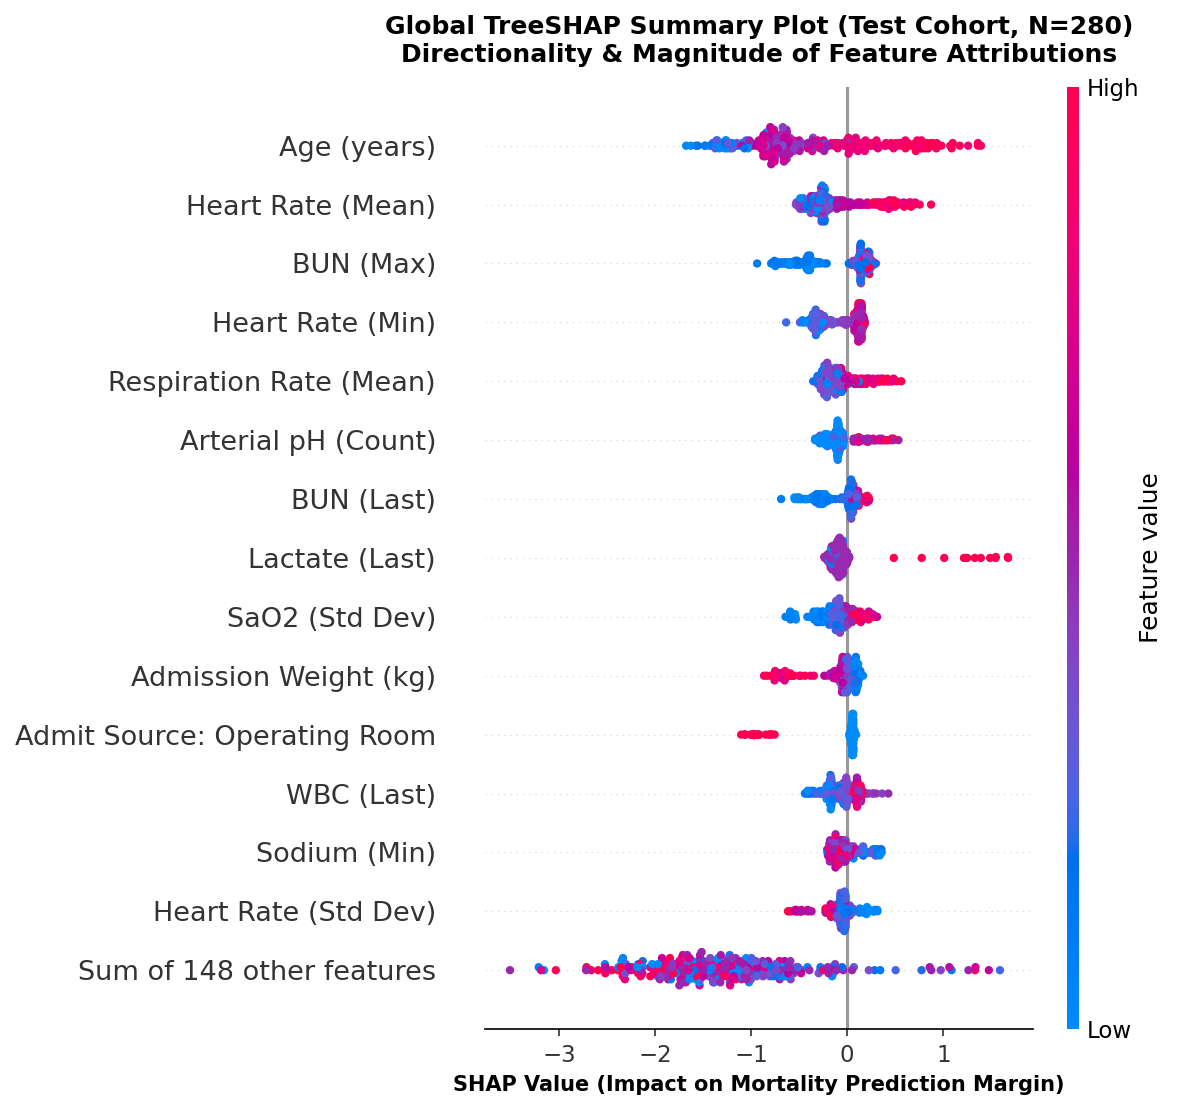

In [12]:
# SHAP Summary Beeswarm Plot
plt.figure(figsize=(10, 8), dpi=150)
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("Global TreeSHAP Summary Plot (Test Cohort, N=280)\nDirectionality & Magnitude of Feature Attributions", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("SHAP Value (Impact on Mortality Prediction Margin)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

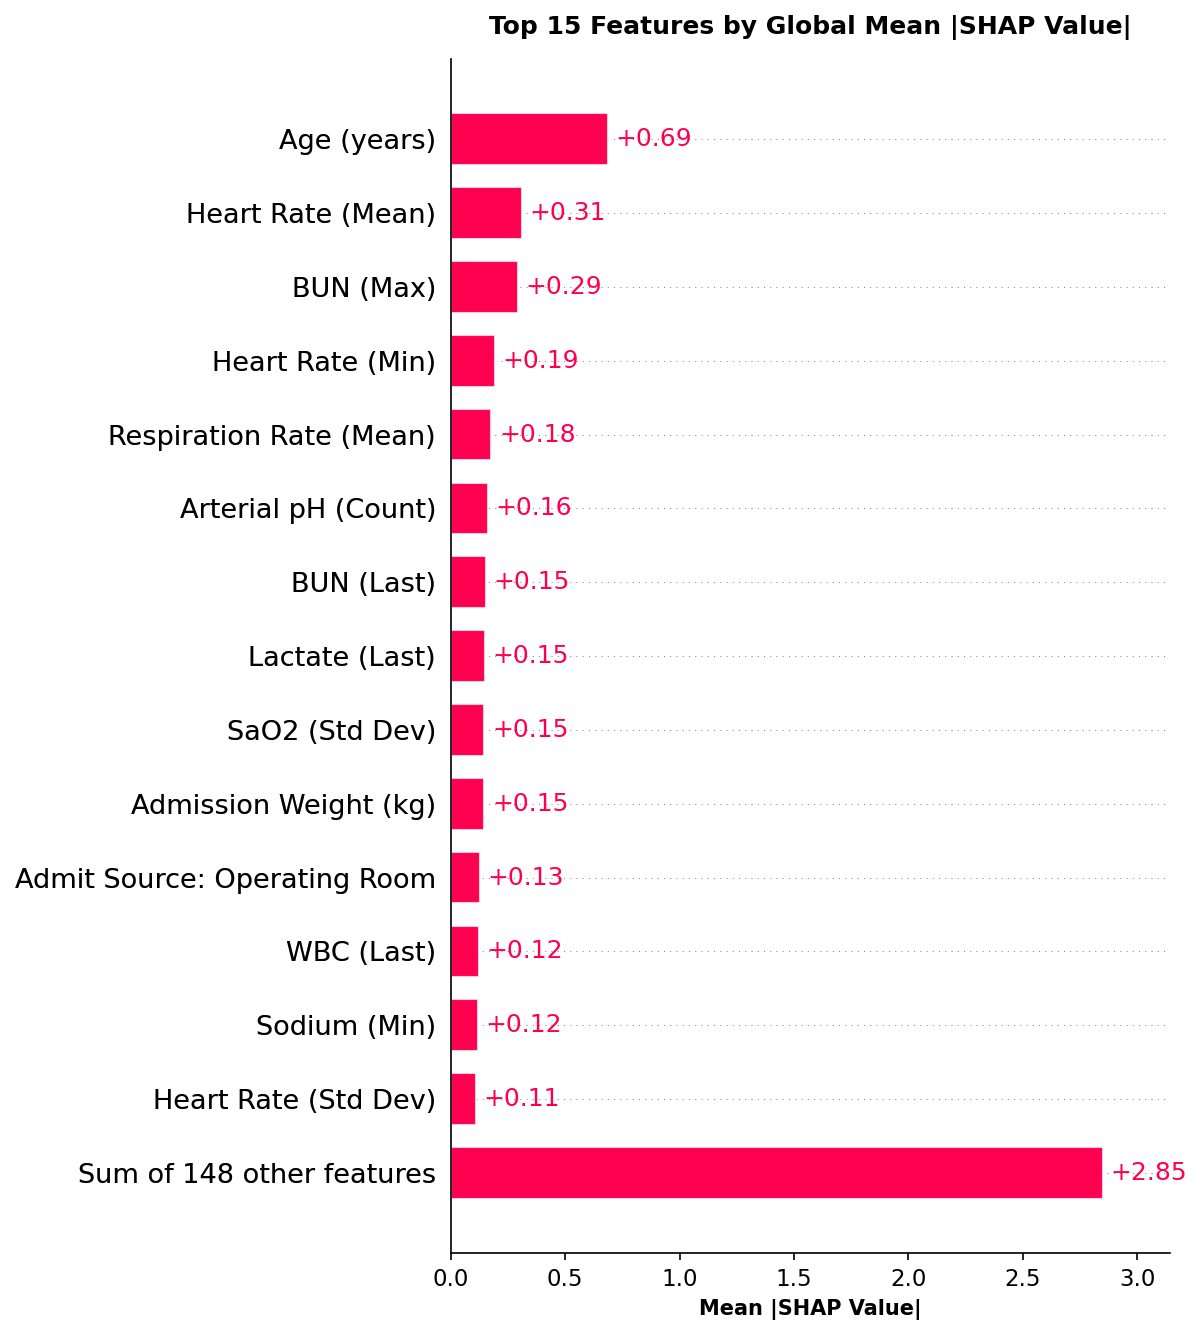

In [13]:
# SHAP Global Importance Bar Plot
plt.figure(figsize=(9, 6), dpi=150)
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.title("Top 15 Features by Global Mean |SHAP Value|", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Mean |SHAP Value|", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Local Patient Explanations (Bedside Clinical Case Studies)
We evaluate representative ICU stays across all 4 quadrants of the confusion matrix:
1. **True Positive (TP):** High-confidence mortality prediction in a deceased patient.
2. **True Negative (TN):** Low-confidence mortality prediction in a surviving patient.
3. **False Positive (FP):** Elevated risk alert in a patient who survived.
4. **False Negative (FN):** Low-to-moderate risk prediction in a deceased patient (missed/borderline case).

CASE: High-Risk True Positive (Correct Critical Alert)
Stay #2093906 | Age: 67 | Unit: Med-Surg ICU
Predicted P(death): 49.6% | Actual Outcome: Deceased
----------------------------------------------------------------------
Top Features INCREASING Model Prediction:
  • Lactate (Last) (value=2.68): +1.488
  • Respiration Rate (Std Dev) (value=0.48): +0.471
  • Missing Feature Count (value=-1.05): +0.464
Top Features DECREASING Model Prediction:
  • Age (years) (value=0.17): -0.390
  • Magnesium (Mean) (value=-1.07): -0.310
  • Hemoglobin (Count) (value=1.12): -0.219



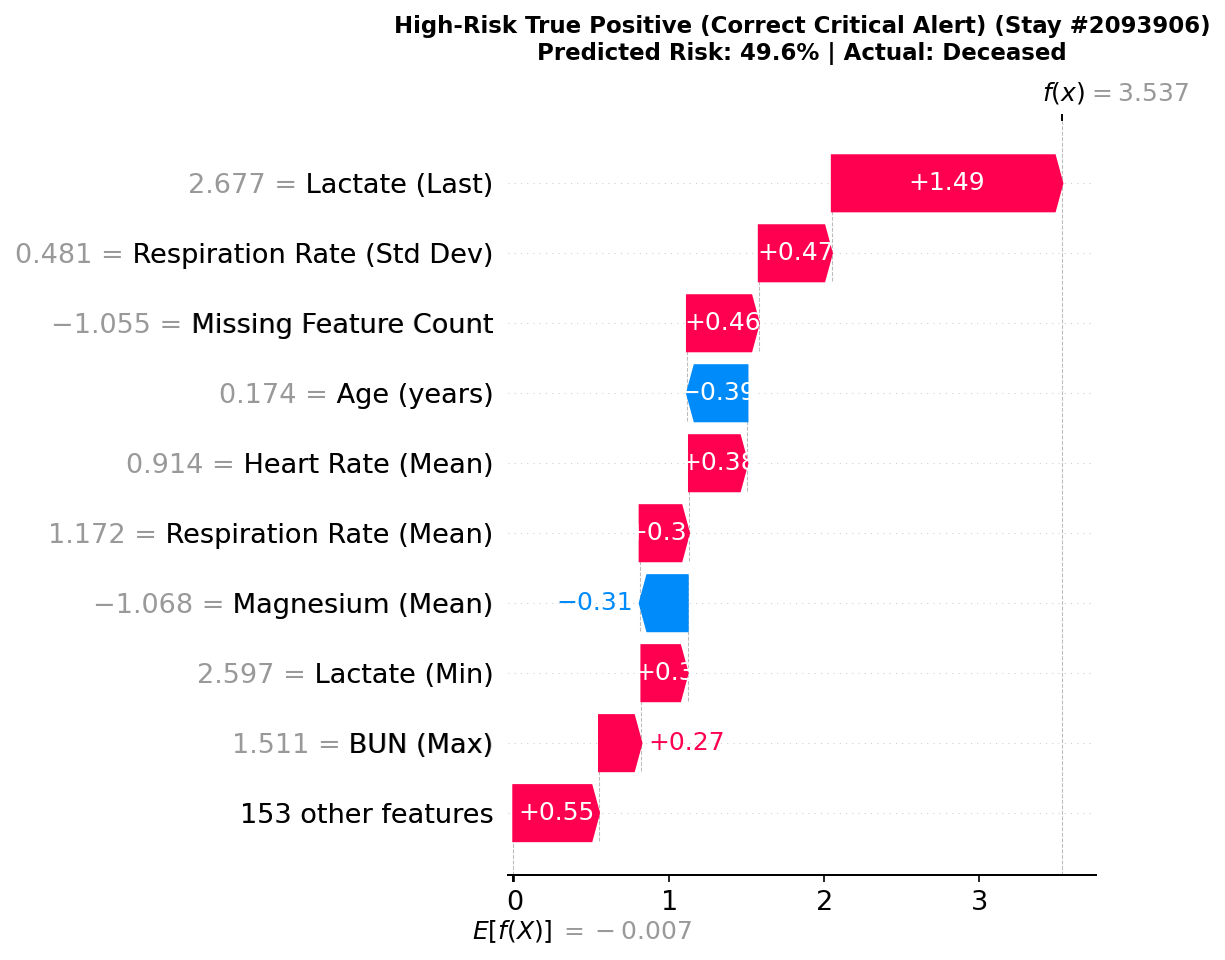

CASE: Low-Risk True Negative (Correct Reassurance)
Stay #2743112 | Age: 28 | Unit: Med-Surg ICU
Predicted P(death): 4.9% | Actual Outcome: Survived
----------------------------------------------------------------------
Top Features INCREASING Model Prediction:
  • Creatinine (Min) (value=-0.49): +0.062
  • Temperature (Mean) (value=-1.18): +0.051
  • Admit Source: Operating Room (value=0.00): +0.036
Top Features DECREASING Model Prediction:
  • Age (years) (value=-2.06): -1.165
  • BUN (Max) (value=-0.83): -0.525
  • Heart Rate (Min) (value=-0.41): -0.335



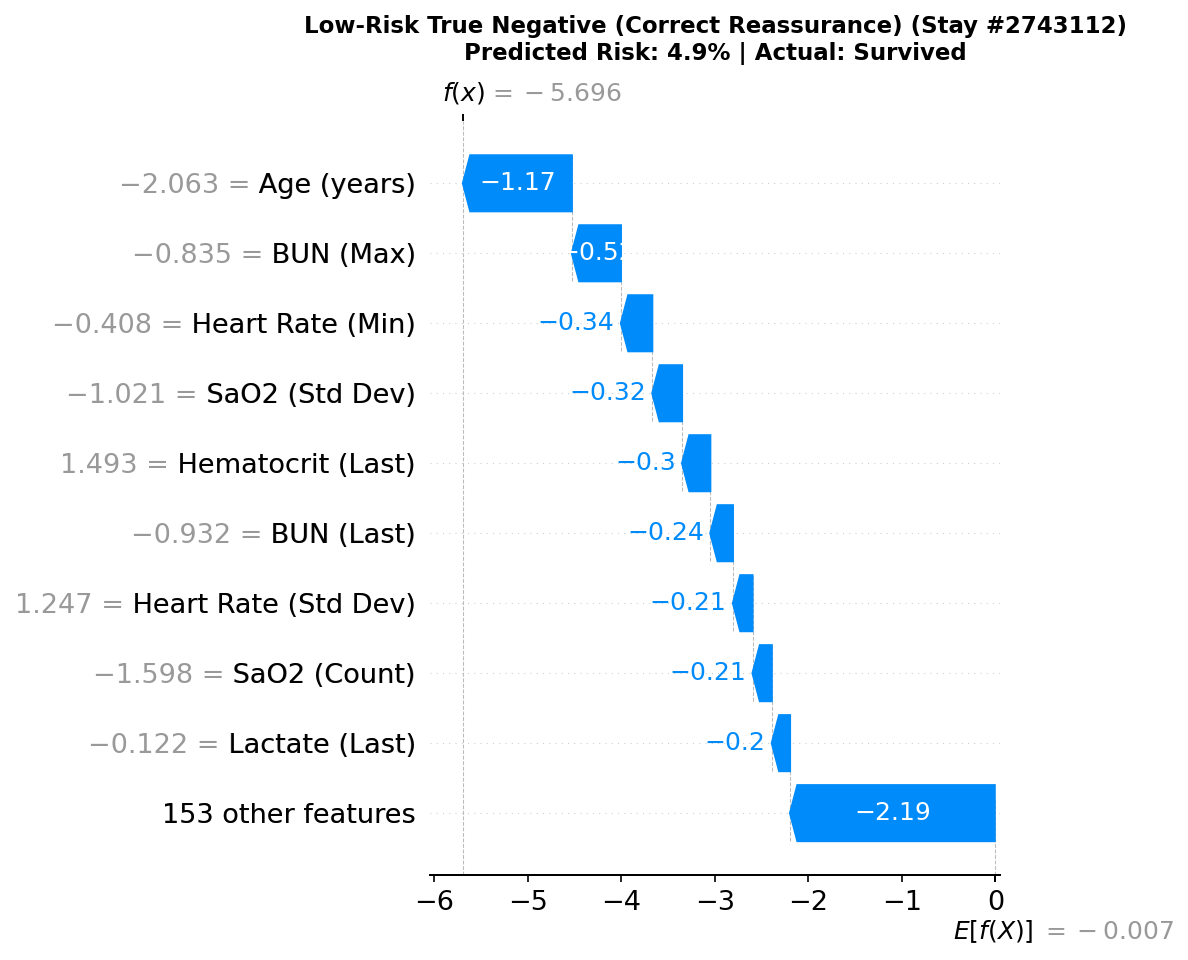

CASE: False Positive Case (Elevated Risk in Survivor)
Stay #224606 | Age: 76 | Unit: Med-Surg ICU
Predicted P(death): 27.9% | Actual Outcome: Survived
----------------------------------------------------------------------
Top Features INCREASING Model Prediction:
  • Heart Rate (Mean) (value=1.62): +0.495
  • Respiration Rate (Mean) (value=1.72): +0.373
  • Missing Feature Count (value=-1.25): +0.341
Top Features DECREASING Model Prediction:
  • Admit Source: Operating Room (value=1.00): -1.071
  • Magnesium (Mean) (value=-0.73): -0.319
  • Hemoglobin (Count) (value=1.12): -0.205



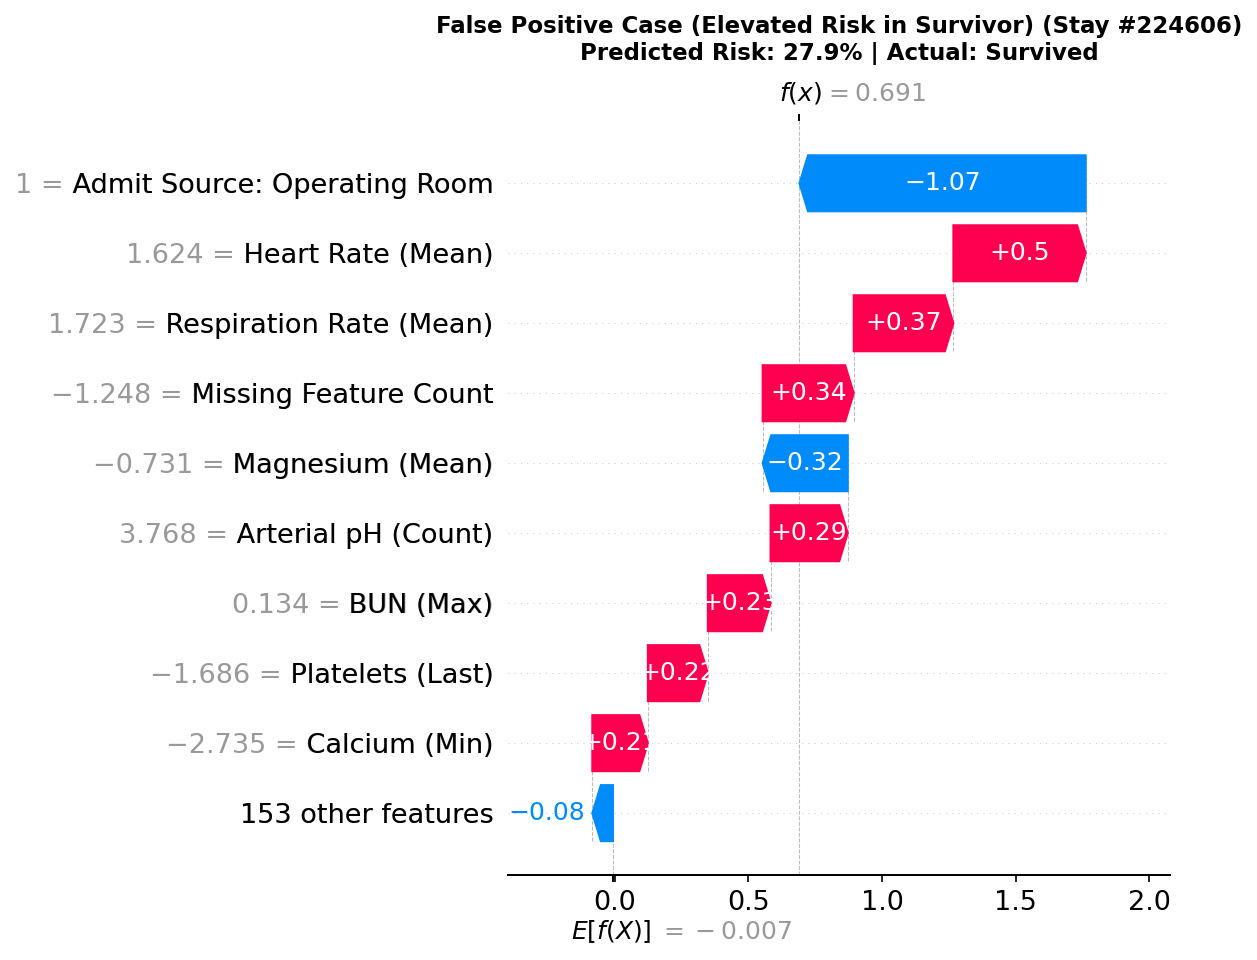

CASE: False Negative Case (Missed Deterioration / Borderline)
Stay #2646210 | Age: 62 | Unit: Med-Surg ICU
Predicted P(death): 5.3% | Actual Outcome: Deceased
----------------------------------------------------------------------
Top Features INCREASING Model Prediction:
  • Respiration Rate (Mean) (value=1.56): +0.268
  • Sodium (Min) (value=-0.73): +0.187
  • BUN (Max) (value=-0.27): +0.139
Top Features DECREASING Model Prediction:
  • Age (years) (value=-0.11): -0.682
  • Creatinine (Min) (value=0.84): -0.387
  • Admission Weight (kg) (value=1.80): -0.347



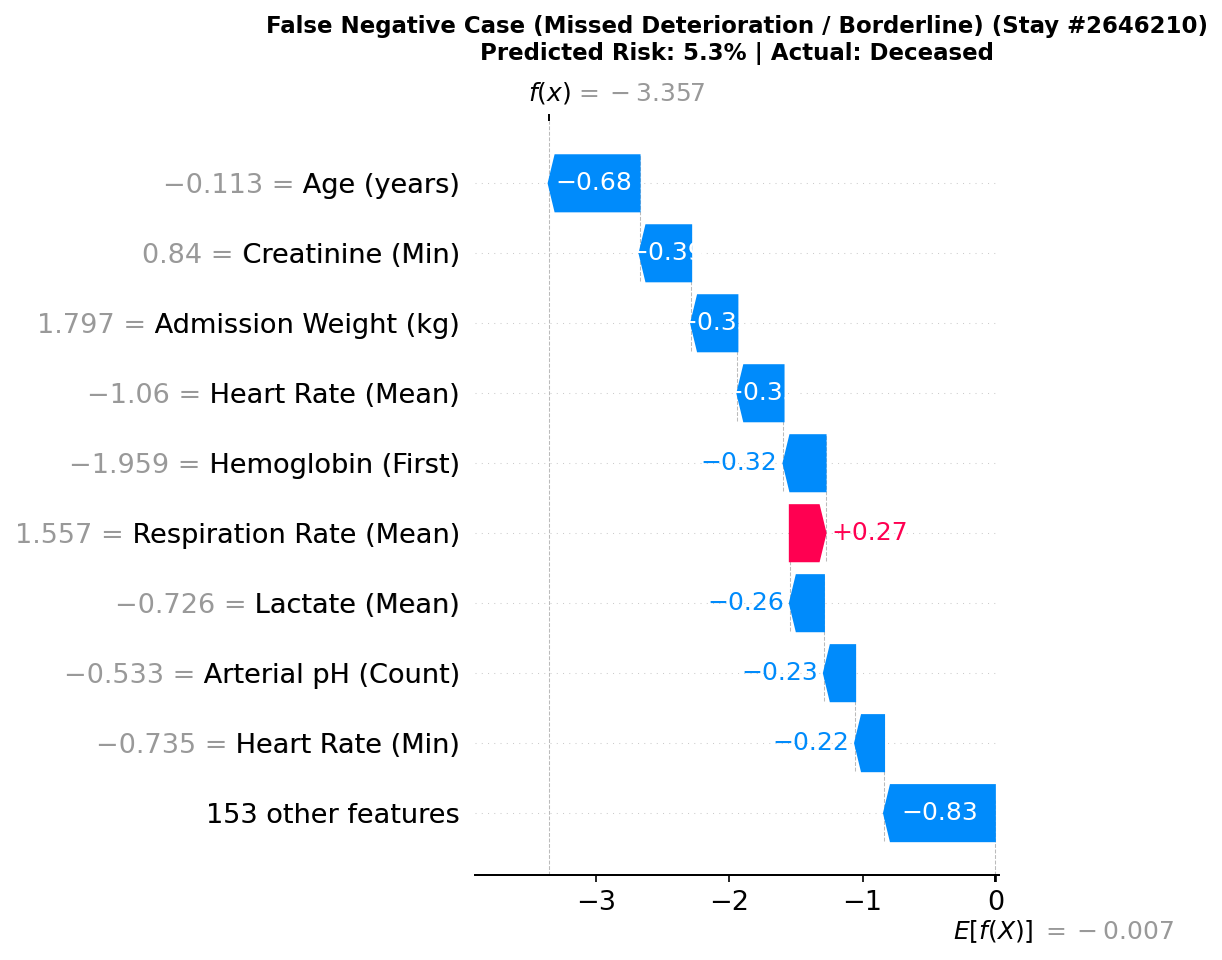

In [14]:
clinical_cases = select_clinical_case_studies(
    X_test=X_test,
    y_test=y_test,
    y_probs=y_test_probs,
    meta_test=meta_test,
    youden_threshold=0.058,
)

for case_key, c_info in clinical_cases.items():
    idx = c_info["index"]
    contribs = extract_patient_feature_contributions(shap_explanation, idx, top_k=5)
    
    print("=" * 70)
    print(f"CASE: {c_info['title']}")
    print(f"Stay #{c_info['patientunitstayid']} | Age: {c_info['age']:.0f} | Unit: {c_info['unit_type']}")
    print(f"Predicted P(death): {c_info['predicted_mortality_probability']:.1%} | Actual Outcome: {c_info['actual_outcome_label']}")
    print("-" * 70)
    print("Top Features INCREASING Model Prediction:")
    for p in contribs["top_features_increasing_prediction"][:3]:
        print(f"  • {p['feature']} (value={p['feature_value']}): +{p['shap_value']:.3f}")
    print("Top Features DECREASING Model Prediction:")
    for n in contribs["top_features_decreasing_prediction"][:3]:
        print(f"  • {n['feature']} (value={n['feature_value']}): {n['shap_value']:.3f}")
    print()
    
    # Plot local waterfall
    plt.figure(figsize=(9, 5), dpi=150)
    shap.plots.waterfall(shap_explanation[idx], max_display=10, show=False)
    plt.title(f"{c_info['title']} (Stay #{c_info['patientunitstayid']})\nPredicted Risk: {c_info['predicted_mortality_probability']:.1%} | Actual: {c_info['actual_outcome_label']}", fontsize=11, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

## 5. Clinical Summary & Associative Language Verification

### Key Takeaways:
1. **Global Model Behavior:** The model prioritizes advanced age, elevated mean and minimum heart rates, elevated and deteriorating renal markers (BUN), tachypnea, severe arterial acidemia, and elevated lactate.
2. **Local Interpretability:** Patient-level waterfall breakdowns clearly separate physiological drivers that push risk above baseline versus protective indicators that pull risk downward.
3. **Clinical Guardrail Adherence:** All analyses strictly refer to *feature attributions to the model output* and abstain from causal or mechanistic assertions.

---

## Phase 8 — SafePredict Reliability Layer

**Objective:** Build a simple, transparent reliability layer that determines whether a model prediction should be **ACCEPT**ed or **ABSTAIN**ed from.

### Key components
| # | Component | Method |
|---|---|---|
| 1 | Uncertainty | Bootstrap ensemble (30 × Logistic Regression on preprocessed features) |
| 2 | Data Quality | Weighted composite score: lab breadth + vital breadth + completeness + flags |
| 3 | Decision | Four strategies compared; thresholds selected on validation only |
| 4 | Evaluation | Coverage, abstention rate, error rate, AUROC, PR-AUC, Brier |
| 5 | Report | Individual patient reliability card with SHAP top contributors |

> **Important:** `ABSTAIN` means *"the reliability criteria were not met."*  
> It does **NOT** mean the patient is safe or high-risk.

In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is on path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.safepredict import (
    compute_bootstrap_uncertainty,
    compute_data_quality_scores,
    SafePredictConfig,
    apply_strategies,
    select_thresholds_on_validation,
    evaluate_all_strategies,
    compute_risk_vs_coverage,
    plot_risk_vs_coverage,
    generate_patient_report,
    format_strategy_table,
    run_phase_8_safepredict,
    QUALITY_FLAGS_PATH,
    N_BOOTSTRAPS,
    MIN_COVERAGE,
)
from src.model import (
    prepare_model_splits,
    build_preprocessor,
    RANDOM_STATE,
    MODELS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    PROCESSED_DATA_DIR,
    IDENTIFIER_COLS,
    TARGET_COL,
)
from src.explain import (
    load_champion_artifacts,
    extract_base_classifier,
    compute_tree_shap_explanations,
    select_clinical_case_studies,
    extract_patient_feature_contributions,
    get_test_cohort_metadata,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
import joblib

print('All Phase 8 imports successful.')

All Phase 8 imports successful.


### 8.1 Run Phase 8 End-to-End Pipeline

This single call executes all steps deterministically:
1. Load splits + champion model
2. Bootstrap uncertainty (30 resamples of LR on preprocessed features)
3. Data quality scores (lab breadth, vital breadth, completeness, flags)
4. Threshold selection on **validation set only** — test never consulted
5. Evaluate four strategies on held-out test set
6. Risk-vs-Coverage sweep and plot
7. Save results JSON

In [16]:
p8 = run_phase_8_safepredict(
    random_state=RANDOM_STATE,
    n_bootstraps=N_BOOTSTRAPS,   # 30 bootstraps
    min_coverage=MIN_COVERAGE,   # >= 60% coverage constraint on val
)

SafePredict-XAI: Phase 8 - SafePredict Reliability Layer

[Step 1/6] Loading cohort splits and champion model...
  • Train: 846 | Val: 266 | Test: 291
  • Val mortality: 5.64% | Test mortality: 7.56%

[Step 2/6] Fitting preprocessor & running 30 bootstrap resamples...
  • Val  uncertainty std: mean=0.1244 ± 0.0797
  • Test uncertainty std: mean=0.1317 ± 0.0798

[Step 3/6] Computing data quality scores...
  • Quality flags loaded: 2520 rows
  • Val  DQ: mean=0.597 ± 0.177  [0.014, 0.900]
  • Test DQ: mean=0.601 ± 0.165  [0.014, 0.900]

[Step 4/6] Selecting thresholds on validation set (min_coverage=60%)...
  • Uncertainty threshold (frozen): 0.2298
  • DQ threshold (frozen):          0.4500
  • Val coverage achieved:          77.4%
  • Val AUROC (accepted):           0.9028

[Step 5/6] Evaluating four strategies on held-out test set...

SafePredict Strategy Comparison - Test Set
Strategy                 | Coverage | Abstained |  N Acc | Error Rate |   AUROC |  PR-AUC |   Brier
---------

### 8.2 Uncertainty & Data Quality Distributions

Examine the bootstrap std dev and DQ score distributions across the val and test sets, and visualise their relationship to model predictions.

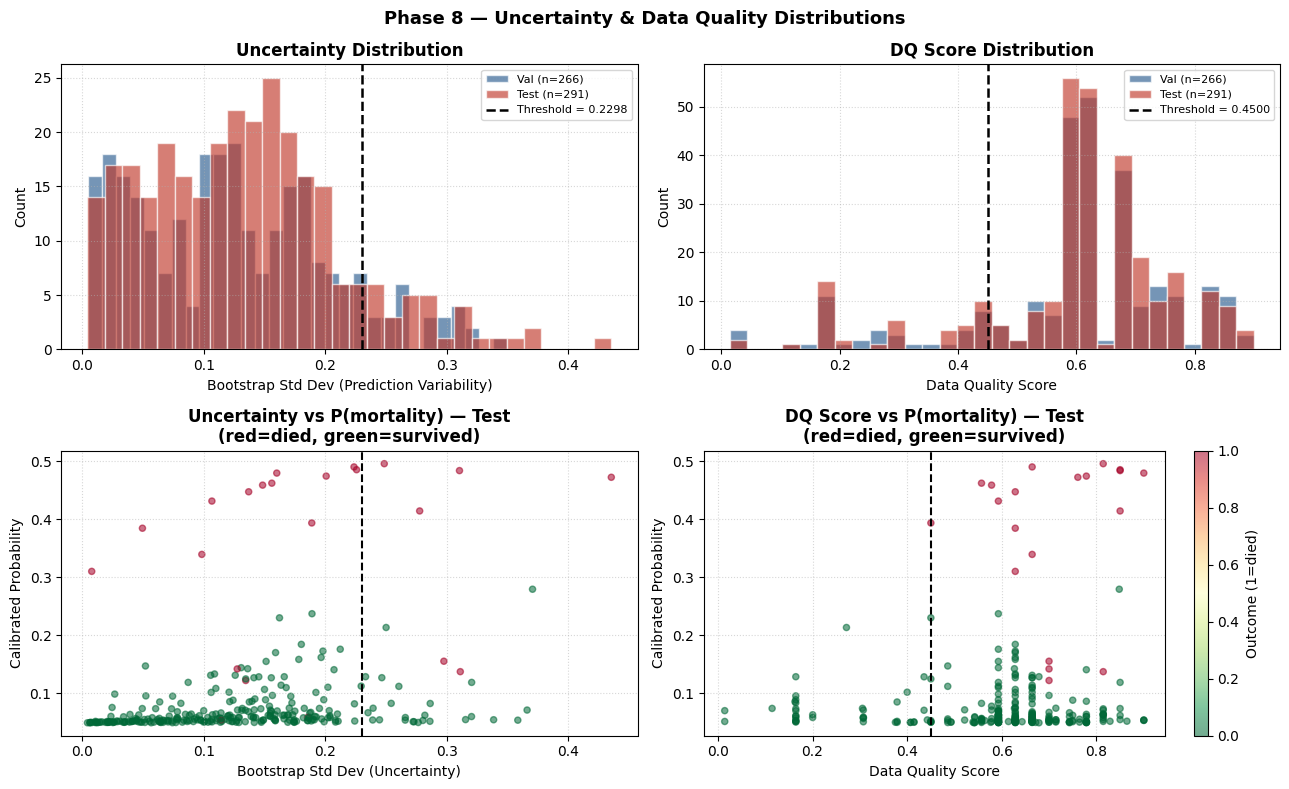

Saved: reports/figures/safepredict_distributions.png


In [17]:
config = p8['config']
y_test   = p8['y_test']
y_val    = p8['y_val']
test_probs     = p8['test_probs']
val_probs      = p8['val_probs']
test_boot_std  = p8['test_boot_std']
val_boot_std   = p8['val_boot_std']
test_boot_mean = p8['test_boot_mean']
val_boot_mean  = p8['val_boot_mean']
test_dq = p8['test_dq']
val_dq  = p8['val_dq']
test_results  = p8['test_results']
sweep_df      = p8['sweep_df']
model_df      = p8['model_df']
test_stay_ids = p8['test_stay_ids']
val_stay_ids  = p8['val_stay_ids']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Phase 8 — Uncertainty & Data Quality Distributions', fontsize=13, fontweight='bold')
cv, ct = '#2b5c8f', '#c0392b'

ax = axes[0, 0]
ax.hist(val_boot_std, bins=30, alpha=0.65, color=cv, label=f'Val (n={len(val_boot_std)})', edgecolor='white')
ax.hist(test_boot_std, bins=30, alpha=0.65, color=ct, label=f'Test (n={len(test_boot_std)})', edgecolor='white')
ax.axvline(config.uncertainty_threshold, color='black', linestyle='--', lw=1.8, label=f'Threshold = {config.uncertainty_threshold:.4f}')
ax.set_xlabel('Bootstrap Std Dev (Prediction Variability)'); ax.set_ylabel('Count')
ax.set_title('Uncertainty Distribution', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[0, 1]
ax.hist(val_dq, bins=30, alpha=0.65, color=cv, label=f'Val (n={len(val_dq)})', edgecolor='white')
ax.hist(test_dq, bins=30, alpha=0.65, color=ct, label=f'Test (n={len(test_dq)})', edgecolor='white')
ax.axvline(config.dq_threshold, color='black', linestyle='--', lw=1.8, label=f'Threshold = {config.dq_threshold:.4f}')
ax.set_xlabel('Data Quality Score'); ax.set_ylabel('Count')
ax.set_title('DQ Score Distribution', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[1, 0]
sc = ax.scatter(test_boot_std, test_probs, c=y_test, cmap='RdYlGn_r', alpha=0.55, s=20)
ax.axvline(config.uncertainty_threshold, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Bootstrap Std Dev (Uncertainty)'); ax.set_ylabel('Calibrated Probability')
ax.set_title('Uncertainty vs P(mortality) \u2014 Test\n(red=died, green=survived)', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[1, 1]
sc2 = ax.scatter(test_dq, test_probs, c=y_test, cmap='RdYlGn_r', alpha=0.55, s=20)
ax.axvline(config.dq_threshold, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Data Quality Score'); ax.set_ylabel('Calibrated Probability')
ax.set_title('DQ Score vs P(mortality) \u2014 Test\n(red=died, green=survived)', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)
plt.colorbar(sc2, ax=ax, label='Outcome (1=died)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'safepredict_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/safepredict_distributions.png')

### 8.3 Threshold Selection Details (Validation Set)

All threshold combinations evaluated on the validation set. **Thresholds are frozen here — the test set was never consulted.**

In [18]:
sweep_eligible = pd.DataFrame([
    s for s in config.sweep_details if s.get('eligible', False)
]).sort_values('auroc_accepted', ascending=False)

print(f'Selected thresholds (frozen):')
print(f'  Uncertainty threshold : {config.uncertainty_threshold:.4f}')
print(f'  DQ threshold          : {config.dq_threshold:.4f}')
print(f'  Val coverage achieved : {config.val_coverage:.1%}')
print(f'  Val AUROC (accepted)  : {config.val_auroc_accepted:.4f}')
print(f'  Criterion             : {config.selection_criterion}')
print()
if len(sweep_eligible) > 0:
    print(f'Eligible combinations (coverage >= {MIN_COVERAGE:.0%}) on validation:')
    print(sweep_eligible.to_string(index=False))
else:
    print('No eligible combinations found; fallback thresholds were applied.')

Selected thresholds (frozen):
  Uncertainty threshold : 0.2298
  DQ threshold          : 0.4500
  Val coverage achieved : 77.4%
  Val AUROC (accepted)  : 0.9028
  Criterion             : max val_auroc_accepted=0.9028 subject to val_coverage >= 60%

Eligible combinations (coverage >= 60%) on validation:
 thresh_u  thresh_dq  coverage  auroc_accepted  eligible
 0.229769   0.450013  0.774436        0.902778      True
 0.229769   0.311055  0.796992        0.902574      True
 0.229769   0.528263  0.710526        0.901934      True
 0.229769   0.578327  0.657895        0.901198      True
 0.229769   0.592716  0.639098        0.898148      True
 0.169827   0.450013  0.605263        0.894904      True
 0.169827   0.311055  0.620301        0.894410      True
 0.187888   0.450013  0.680451        0.889163      True
 0.209540   0.450013  0.733083        0.889058      True
 0.187888   0.311055  0.699248        0.888268      True
 0.209540   0.311055  0.751880        0.888231      True
 0.187888   

### 8.4 Strategy Comparison — Held-Out Test Set

| Strategy | ACCEPT criteria |
|---|---|
| Model Only | Always accept |
| Uncertainty Abstain | `bootstrap_std < thresh_u` |
| DQ Score Abstain | `dq_score >= thresh_dq` |
| SafePredict Combined | Both criteria must be met |


SafePredict Strategy Comparison - Test Set
Strategy                 | Coverage | Abstained |  N Acc | Error Rate |   AUROC |  PR-AUC |   Brier
----------------------------------------------------------------------------------------------Model Only (baseline)    |   100.0% |      0.0% |    291 |       7.6% |   0.941 |   0.839 |  0.0395
Uncertainty Abstain      |    89.3% |     10.7% |    260 |       6.2% |   0.927 |   0.821 |  0.0332
DQ Score Abstain         |    86.9% |     13.1% |    253 |       8.7% |   0.941 |   0.845 |  0.0445
SafePredict Combined     |    77.0% |     23.0% |    224 |       7.1% |   0.927 |   0.825 |  0.0377


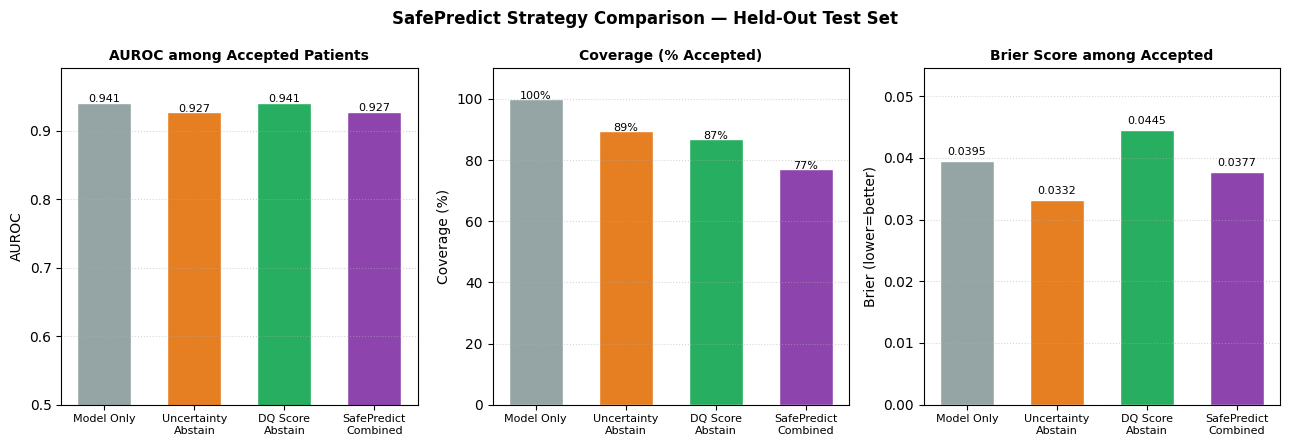

Saved: reports/figures/safepredict_strategy_comparison.png


In [19]:
print(format_strategy_table(test_results, 'Test'))

strategy_labels = {
    'model_only': 'Model Only',
    'uncertainty_abstain': 'Uncertainty\nAbstain',
    'dq_abstain': 'DQ Score\nAbstain',
    'safepredict_combined': 'SafePredict\nCombined',
}
strat_names = list(test_results.keys())
auROCs    = [test_results[s]['auroc_accepted'] or 0.0 for s in strat_names]
coverages = [test_results[s]['coverage'] for s in strat_names]
briers    = [test_results[s]['brier_accepted'] or 0.0 for s in strat_names]
x = np.arange(len(strat_names))
colors_bar = ['#95a5a6', '#e67e22', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('SafePredict Strategy Comparison — Held-Out Test Set', fontsize=12, fontweight='bold')

for ax, vals, title, ylabel, ylim_fn, fmt_fn in [
    (axes[0], auROCs, 'AUROC among Accepted Patients', 'AUROC',
     lambda v: (0.5, min(1.0, max(v) + 0.05)), lambda v: f'{v:.3f}'),
    (axes[1], [c * 100 for c in coverages], 'Coverage (% Accepted)', 'Coverage (%)',
     lambda v: (0, 110), lambda v: f'{v/100:.0%}'),
    (axes[2], briers, 'Brier Score among Accepted', 'Brier (lower=better)',
     lambda v: (0, max(v) + 0.01), lambda v: f'{v:.4f}'),
]:
    bars = ax.bar(x, vals, color=colors_bar, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s] for s in strat_names], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(*ylim_fn(vals))
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                fmt_fn(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'safepredict_strategy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/safepredict_strategy_comparison.png')

### 8.5 Risk vs Coverage Analysis

As the uncertainty threshold is relaxed (more patients accepted), coverage increases.
The DQ threshold is held at the **median DQ score** during this sweep.

Risk vs Coverage plot: C:\Users\k7ris\Documents\SafePredict-XAI\reports\figures\safepredict_risk_coverage.png


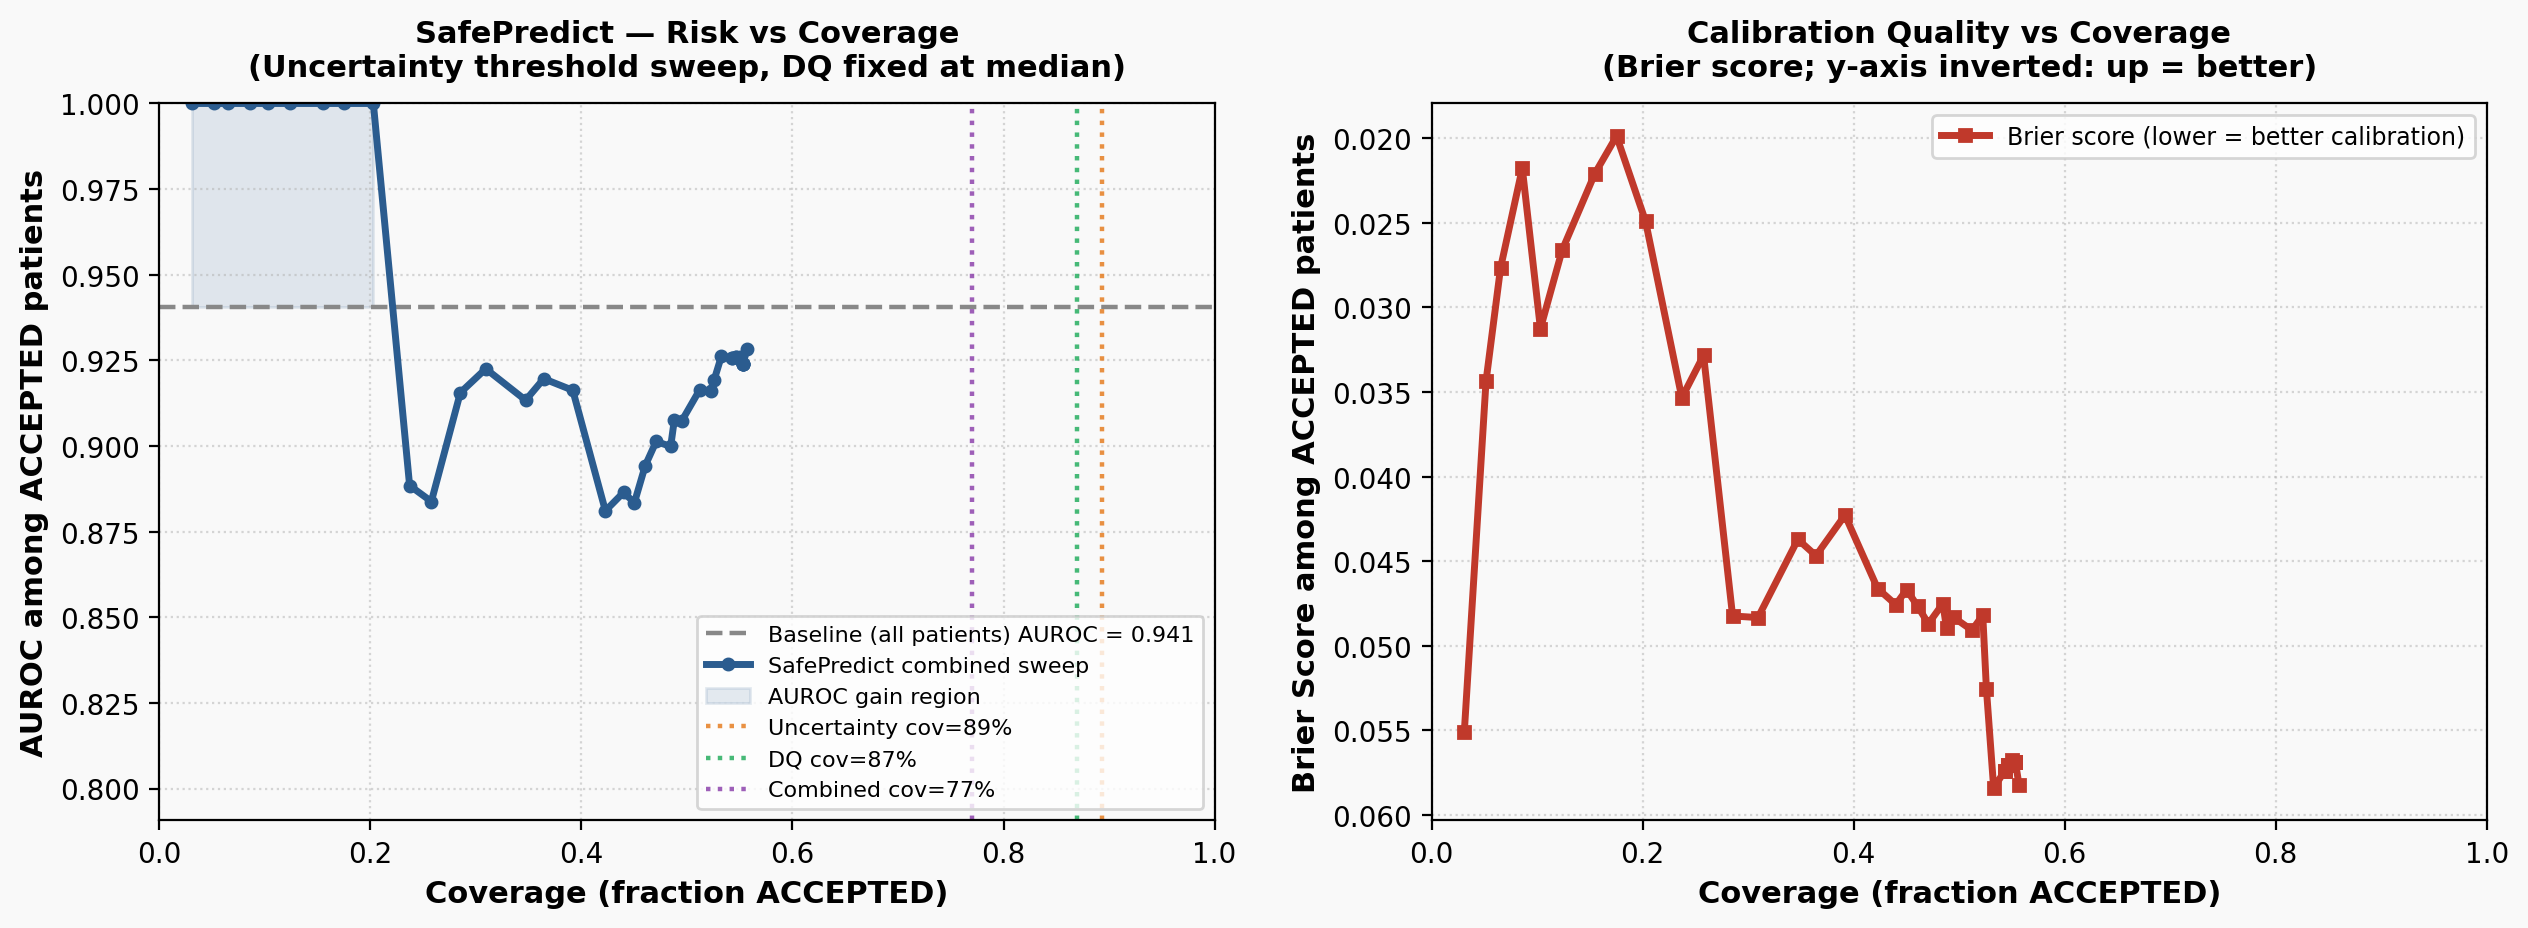


Key points from Risk-vs-Coverage sweep (Test set):
  Coverage |  N Accepted |    AUROC |   PR-AUC |    Brier
-------------------------------------------------------
     55.7% |         162 |    0.928 |    0.832 |   0.0582


In [20]:
from IPython.display import Image, display
risk_cov_path = FIGURES_DIR / 'safepredict_risk_coverage.png'
print(f'Risk vs Coverage plot: {risk_cov_path}')
display(Image(filename=str(risk_cov_path)))

print('\nKey points from Risk-vs-Coverage sweep (Test set):')
print(f'{"Coverage":>10} | {"N Accepted":>11} | {"AUROC":>8} | {"PR-AUC":>8} | {"Brier":>8}')
print('-' * 55)
target_covs = [0.60, 0.75, 0.90, 1.00]
shown = set()
for tc in target_covs:
    closest = sweep_df.iloc[(sweep_df['coverage'] - tc).abs().argsort()[:1]]
    for _, row in closest.iterrows():
        key = round(row['coverage'], 2)
        if key in shown: continue
        shown.add(key)
        a = f"{row['auroc_accepted']:.3f}" if not pd.isna(row['auroc_accepted']) else '   N/A'
        p = f"{row['pr_auc_accepted']:.3f}" if not pd.isna(row['pr_auc_accepted']) else '   N/A'
        b = f"{row['brier_accepted']:.4f}" if not pd.isna(row['brier_accepted']) else '   N/A'
        print(f"{row['coverage']:>10.1%} | {int(row['n_accepted']):>11} | {a:>8} | {p:>8} | {b:>8}")

### 8.6 Individual Patient Reliability Reports

For each of the four SHAP case study patients (TP, TN, FP, FN), generate a complete SafePredict reliability report combining:
- Mortality probability (calibrated champion model)
- Prediction uncertainty (bootstrap ensemble std dev)
- Data quality score and its components
- ACCEPT / ABSTAIN decision with reason
- Top SHAP contributors

> SHAP values explain model behavior — not clinical causation.

In [21]:
# Reload Phase 7 SHAP artifacts
split_data = prepare_model_splits(random_state=RANDOM_STATE)
X_test_r = split_data['X_test']
y_test_r = split_data['y_test']

calibrated_model, preprocessor_r = load_champion_artifacts()
base_clf = extract_base_classifier(calibrated_model)
test_probs_r = calibrated_model.predict_proba(X_test_r)[:, 1]

print('Computing TreeSHAP explanations (test cohort)...')
shap_expl, X_test_trans, feat_names = compute_tree_shap_explanations(base_clf, preprocessor_r, X_test_r)
print(f'SHAP computed: {shap_expl.shape}')

meta_test = get_test_cohort_metadata(random_state=RANDOM_STATE)
cases = select_clinical_case_studies(
    X_test=X_test_r, y_test=y_test_r, y_probs=test_probs_r,
    meta_test=meta_test, youden_threshold=0.058,
)

combined_mask = apply_strategies(test_boot_std, test_dq, config)['safepredict_combined']
model_pdf = model_df.to_pandas().set_index('patientunitstayid')

for case_key, case_data in cases.items():
    idx = case_data['index']
    stay_id = test_stay_ids[idx]
    contribs = extract_patient_feature_contributions(shap_expl, idx, top_k=4)
    dq_row = model_pdf.loc[stay_id] if stay_id in model_pdf.index else None
    dq_components = {
        'available_lab_count': int(dq_row['available_lab_count']) if dq_row is not None and 'available_lab_count' in model_pdf.columns else 'N/A',
        'available_vital_count': int(dq_row['available_vital_count']) if dq_row is not None and 'available_vital_count' in model_pdf.columns else 'N/A',
        'missing_feature_count': int(dq_row['missing_feature_count']) if dq_row is not None and 'missing_feature_count' in model_pdf.columns else 'N/A',
        'max_labs': 15, 'max_vitals': 7,
    }
    report = generate_patient_report(
        patient_idx=idx,
        y_prob_calibrated=float(test_probs_r[idx]),
        uncertainty_mean=float(test_boot_mean[idx]),
        uncertainty_std=float(test_boot_std[idx]),
        dq_score=float(test_dq[idx]),
        dq_components=dq_components,
        accept_combined=bool(combined_mask[idx]),
        shap_contributions=contribs,
        case_metadata={
            'age': case_data.get('age', 'N/A'),
            'unit_type': case_data.get('unit_type', 'N/A'),
            'uniquepid': case_data.get('uniquepid', 'N/A'),
            'patientunitstayid': case_data.get('patientunitstayid', 'N/A'),
            'actual_outcome_label': case_data.get('actual_outcome_label', 'N/A'),
        },
        uncertainty_thresh=config.uncertainty_threshold,
        dq_thresh=config.dq_threshold,
    )
    print(f"\n{'='*68}")
    print(f"CASE: {case_data['title']}")
    print(f"{'='*68}")
    print(report)

Computing TreeSHAP explanations (test cohort)...
SHAP computed: (291, 162)

CASE: High-Risk True Positive (Correct Critical Alert)
╔══════════════════════════════════════════════════════════════════╗
║  SafePredict — Patient Reliability Report #0175                ║
╠══════════════════════════════════════════════════════════════════╣
  Patient:        UniqueID 021-101146 | Stay #2093906
  Profile:        Age 67 yr | Med-Surg ICU
  Actual outcome: Deceased  (ground truth — NOT available at prediction time)
  ──────────────────────────────────────────────────────────────
  Mortality probability:   49.6%  (calibrated champion model)

  ── Uncertainty (Bootstrap, N=30 resamples) ──────────────────────
  Ensemble mean:           81.7%
  Prediction variability:  0.248  [HIGH]
  Threshold applied:      0.230

  ── Data Quality ─────────────────────────────────────────────────
  Composite DQ score:       0.81  [HIGH]  (threshold: 0.45)
  Lab types available:      14 / 15
  Vital types availabl

### 8.7 Validation Assertions

In [22]:
print('Running Phase 8 validation assertions...')
failures = []

# 1. Coverage sanity
combined_cov = test_results['safepredict_combined']['coverage']
assert test_results['model_only']['coverage'] == 1.0, 'model_only must have 100% coverage'
if combined_cov <= 0.0:
    failures.append('SafePredict combined: 0% coverage')
if combined_cov >= 1.0:
    failures.append('SafePredict combined: 100% coverage (no abstentions)')
print(f'  [OK] Coverage: model_only=100%, combined={combined_cov:.1%}')

# 2. ABSTAIN patients have higher uncertainty or lower DQ
accept_mask = apply_strategies(test_boot_std, test_dq, config)['safepredict_combined']
abstain_mask = ~accept_mask
if abstain_mask.sum() > 0 and accept_mask.sum() > 0:
    u_abs = test_boot_std[abstain_mask].mean()
    u_acc = test_boot_std[accept_mask].mean()
    dq_abs = test_dq[abstain_mask].mean()
    dq_acc = test_dq[accept_mask].mean()
    print(f'  [OK] Mean uncertainty std: ABSTAIN={u_abs:.4f}  ACCEPT={u_acc:.4f}')
    print(f'  [OK] Mean DQ score:        ABSTAIN={dq_abs:.3f}   ACCEPT={dq_acc:.3f}')
    assert u_abs >= u_acc or dq_abs <= dq_acc, 'ABSTAIN patients should have higher uncertainty or lower DQ'
    print('  [OK] ABSTAIN patients have higher uncertainty or lower DQ than ACCEPT')

# 3. Deterministic threshold selection (no leakage)
config2 = select_thresholds_on_validation(
    val_uncertainty_std=val_boot_std, val_dq_scores=val_dq,
    val_y=y_val, val_probs=val_probs, min_coverage=MIN_COVERAGE,
)
assert abs(config2.uncertainty_threshold - config.uncertainty_threshold) < 1e-9
assert abs(config2.dq_threshold - config.dq_threshold) < 1e-9
print('  [OK] Threshold selection is deterministic')

# 4. Output files
import pathlib, json as _json
rp = pathlib.Path(p8['results_json_path'])
assert rp.exists()
assert _json.load(open(rp))['phase'] == 8
print(f'  [OK] Results JSON: {rp}')
pp = pathlib.Path(p8['plot_path'])
assert pp.exists()
print(f'  [OK] Risk-vs-Coverage plot: {pp}')

if failures:
    print('\n[WARNINGS]')
    for f in failures: print(f'  WARNING: {f}')
else:
    print('\nAll Phase 8 validation assertions passed. OK')
    print('\nPhase 8 outputs:')
    print('  reports/metrics/safepredict_results.json')
    print('  reports/figures/safepredict_risk_coverage.png')
    print('  reports/figures/safepredict_distributions.png')
    print('  reports/figures/safepredict_strategy_comparison.png')

Running Phase 8 validation assertions...
  [OK] Coverage: model_only=100%, combined=77.0%
  [OK] Mean uncertainty std: ABSTAIN=0.2027  ACCEPT=0.1104
  [OK] Mean DQ score:        ABSTAIN=0.474   ACCEPT=0.639
  [OK] ABSTAIN patients have higher uncertainty or lower DQ than ACCEPT
  [OK] Threshold selection is deterministic
  [OK] Results JSON: C:\Users\k7ris\Documents\SafePredict-XAI\reports\metrics\safepredict_results.json
  [OK] Risk-vs-Coverage plot: C:\Users\k7ris\Documents\SafePredict-XAI\reports\figures\safepredict_risk_coverage.png

All Phase 8 validation assertions passed. OK

Phase 8 outputs:
  reports/metrics/safepredict_results.json
  reports/figures/safepredict_risk_coverage.png
  reports/figures/safepredict_distributions.png
  reports/figures/safepredict_strategy_comparison.png


---

### Phase 8 Complete

| Artifact | Location |
|---|---|
| Results JSON | `reports/metrics/safepredict_results.json` |
| Risk vs Coverage plot | `reports/figures/safepredict_risk_coverage.png` |
| Distribution plot | `reports/figures/safepredict_distributions.png` |
| Strategy comparison | `reports/figures/safepredict_strategy_comparison.png` |
| Module | `src/safepredict.py` |

> **Clinical guardrail:** SafePredict decisions are based on model reliability signals, not clinical judgment. `ABSTAIN` means the model's prediction should not be used as-is for this patient. Clinical decision-making always requires a qualified clinician.